In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


2025-01-06 16:17:44.349808: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-06 16:17:44.360005: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-06 16:17:44.364784: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-06 16:17:44.374373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736176664.394324   15098 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736176664.40

Num GPUs Available:  0


2025-01-06 16:17:46.653040: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
!pip install datasets


  Using cached fsspec-2024.9.0-py3-none-any.whl.metadata (11 kB)
Using cached fsspec-2024.9.0-py3-none-any.whl (179 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 14.7 MB/s eta 0:00:00m eta 0:00:010:01:01
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0


In [3]:
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 14.4 MB/s eta 0:00:00MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 13.0 MB/s eta 0:00:00 MB/s eta 0:00:01


**Snippet from assignment**

In [3]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from transformers import AutoTokenizer


# Load dataset
dataset = load_dataset('ag_news')

# Load model and tokenizer - FINE-TUNED
# model_fineTuned = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4, )
model_fineTuned = BertForSequenceClassification.from_pretrained(
    "./models/fine_tuned_model",
    num_labels=4,
    output_attentions=True  # Enable attention outputs
)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocess data
def preprocess_func(examples):
  return tokenizer(examples['text'], truncation=True, padding="max_length", max_length = 128)

encoded_dataset = dataset.map(preprocess_func, batched=True)
encoded_dataset = encoded_dataset.remove_columns(["text"])  # Keep only model-relevant columns
encoded_dataset = encoded_dataset.rename_column("label", "labels")


# # Training arguments
# training_args= TrainingArguments(
#     output_dir = "./results",
#     evaluation_strategy = "epoch",
#     save_strategy = "epoch",
#     learning_rate = 2e-5,
#     per_device_train_batch_size = 16,
#     num_train_epochs = 3
# )

# trainer = Trainer(
#     model = model_fineTuned,
#     args = training_args,
#     train_dataset = encoded_dataset["train"],
#     eval_dataset = encoded_dataset["test"]
# )

# trainer.train()

# Save the fine-tuned model locally
# model_fineTuned.save_pretrained("./models/fine_tuned_model")

In [4]:
print(dataset["train"].column_names)

from collections import Counter

# Initialize an empty Counter
total_counts = Counter()

# Iterate through all splits in the dataset
for split in dataset:
    labels = dataset[split]["label"]
    total_counts.update(labels)

# Display results
for label, count in total_counts.items():
    print(f"Class {label}: {count} examples")


['text', 'label']
Class 2: 31900 examples
Class 3: 31900 examples
Class 1: 31900 examples
Class 0: 31900 examples


**3.4 - Extracting attention maps**

In [4]:
# Snippet from hand-out, adapted

from transformers import BertTokenizer, BertModel
import torch
from transformers import AutoTokenizer


# Put models on the same device
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_pretrained = BertModel.from_pretrained("bert-base-uncased",
                                             output_attentions=True)
tokenizer_pretrained = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Example input
inputs_unseen1 = tokenizer("The Massachusetts Legislature approved a bill Monday aimed at closing loopholes in the state’s health care market regulatory process exposed by the collapse of Steward Health Care.", return_tensors="pt")

# Move the models to the correct device
model_pretrained.to(device)
model_fineTuned.to(device)

# Move the inputs to the correct device
inputs_unseen1 = {key: value.to(device) for key, value in inputs_unseen1.items()}

# Get attentions
# Pre-trained
outputs1_pretrained = model_pretrained(**inputs_unseen1)
attentions1_pretrained = outputs1_pretrained.attentions
#Fine-tuned
outputs1_fineTuned = model_fineTuned(**inputs_unseen1)
attentions1_fineTuned = outputs1_fineTuned.attentions

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [6]:
# Inspect tokens to see if [CLS] is there (as the first token)
# ANSWER: Yes, it is.

# Decode the input_ids to check the tokens
decoded_tokens = tokenizer.decode(inputs_unseen1["input_ids"][0])  # Decode the first sequence

# Split the decoded tokens into a list for easier inspection
tokens_list = tokenizer.convert_ids_to_tokens(inputs_unseen1["input_ids"][0])

# Print the results
print("Decoded Tokens:", decoded_tokens)
print("Token List:", tokens_list)

# Check the first token
if tokens_list[0] == "[CLS]":
    print("The first token is [CLS].")
else:
    print("The first token is NOT [CLS].")


Decoded Tokens: [CLS] the massachusetts legislature approved a bill monday aimed at closing loopholes in the state ’ s health care market regulatory process exposed by the collapse of steward health care. [SEP]
Token List: ['[CLS]', 'the', 'massachusetts', 'legislature', 'approved', 'a', 'bill', 'monday', 'aimed', 'at', 'closing', 'loop', '##holes', 'in', 'the', 'state', '’', 's', 'health', 'care', 'market', 'regulatory', 'process', 'exposed', 'by', 'the', 'collapse', 'of', 'steward', 'health', 'care', '.', '[SEP]']
The first token is [CLS].


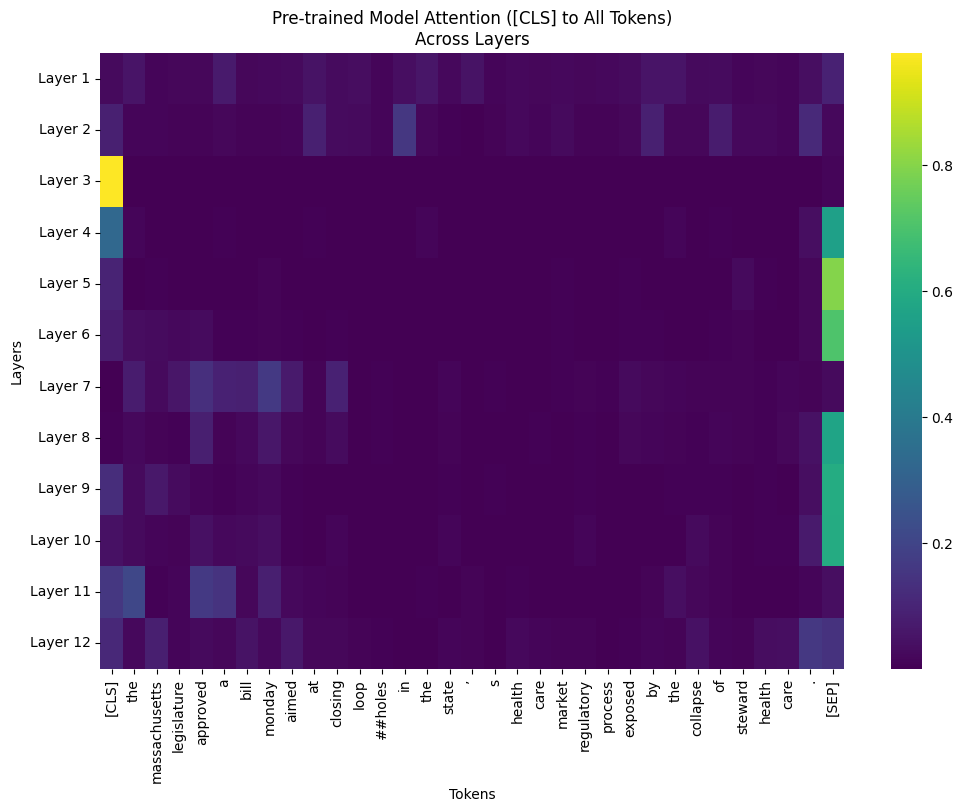

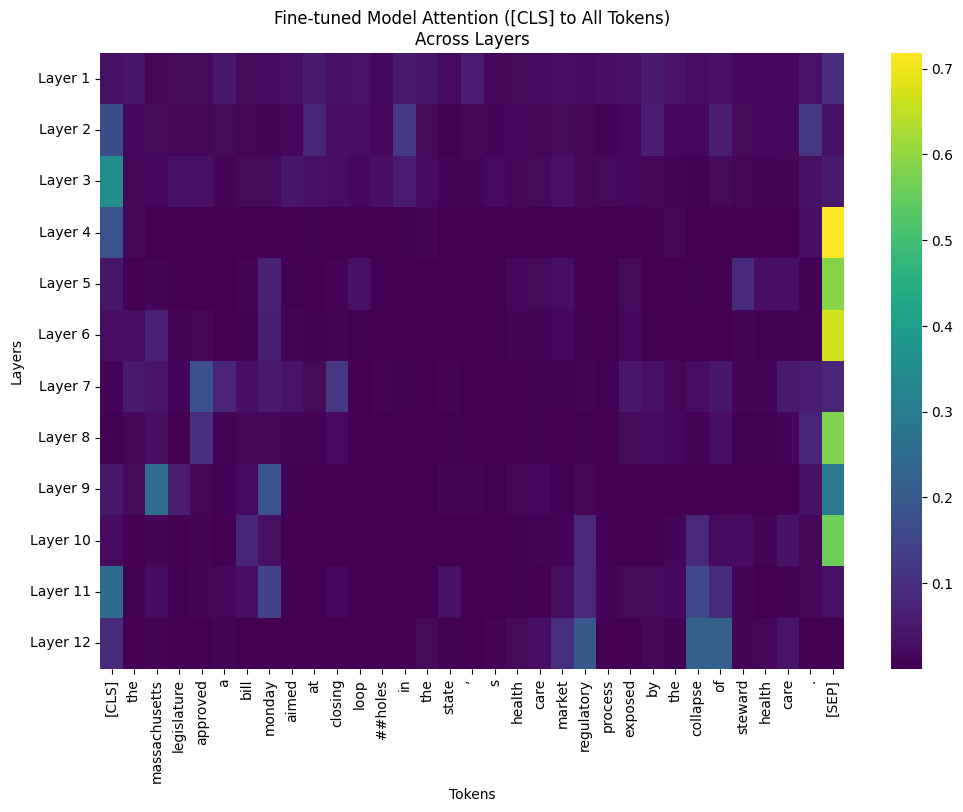

In [10]:
def plot_cls_attention_over_layers(attentions, tokens, title):
    """
    Visualize attentions from the [CLS] token to all other tokens across all layers.
    """
    # Extract attention scores for the first head and the [CLS] token (index 0) across all layers
    cls_attentions = [layer[0, 0, 0, :].detach().cpu().numpy() for layer in attentions]
    cls_attentions = np.array(cls_attentions)  # Shape: (12 layers, seq_len)

    # Create a heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(cls_attentions, cmap="viridis", xticklabels=tokens, 
                yticklabels=[f"Layer {i+1}" for i in range(len(cls_attentions))])
    plt.title(title)
    plt.xlabel("Tokens")
    plt.ylabel("Layers")
    plt.xticks(rotation=90)
    plt.show()

# Convert token IDs to tokens
tokens = tokenizer.convert_ids_to_tokens(inputs_unseen1["input_ids"][0])

# Pre-trained attention
plot_cls_attention_over_layers(attentions1_pretrained,
                               tokens,
                               "Pre-trained Model Attention ([CLS] to All Tokens)\nAcross Layers")

# Fine-tuned attention
plot_cls_attention_over_layers(attentions1_fineTuned,
                               tokens,
                               "Fine-tuned Model Attention ([CLS] to All Tokens)\nAcross Layers")


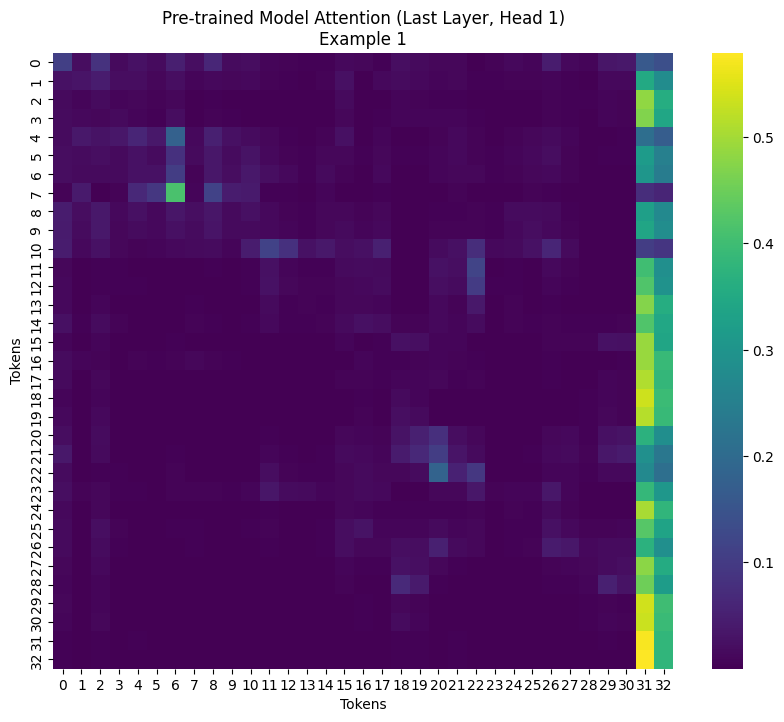

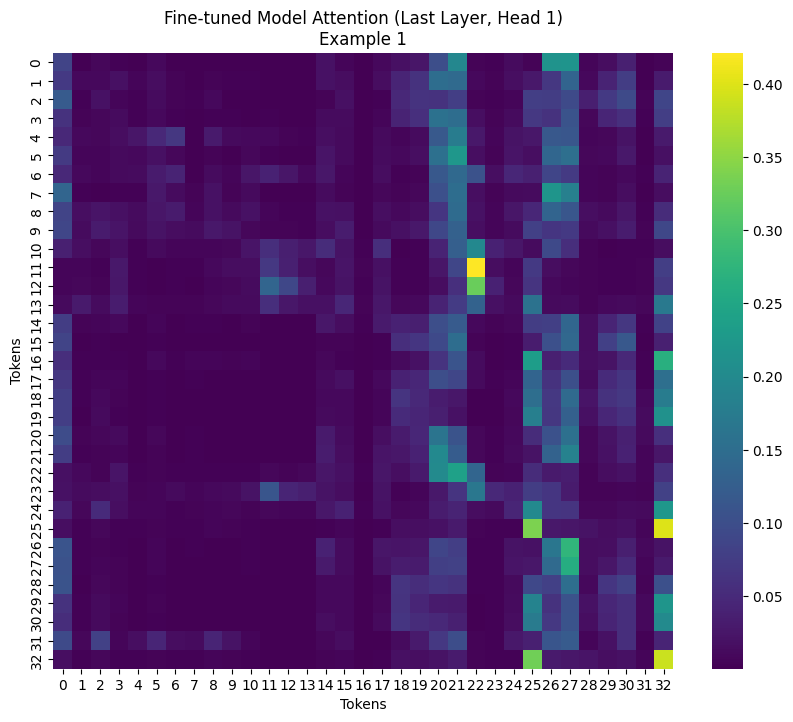

In [6]:
# COMPARISON OF ATTENTION MAPS - VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

# Example: Visualize attention from the last layer, first head
def plot_attention(attention_map, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_map[0][0].detach().cpu().numpy(), cmap="viridis")
    plt.title(title)
    plt.xlabel("Tokens")
    plt.ylabel("Tokens")
    plt.show()

# Pre-trained attention
plot_attention(attentions1_pretrained[-1],
               "Pre-trained Model Attention (Last Layer, Head 1)\nExample 1")

# Fine-tuned attention
plot_attention(attentions1_fineTuned[-1], "Fine-tuned Model Attention (Last Layer, Head 1)\nExample 1")


In [ ]:
# print(inputs_unseen1)
print(attentions1_fineTuned)

(tensor([[[[3.0007e-02, 4.0240e-02, 1.3771e-02,  ..., 1.5546e-02,
           3.3790e-02, 9.0735e-02],
          [4.5144e-02, 3.1350e-02, 3.3715e-02,  ..., 2.4188e-02,
           2.9548e-02, 2.7260e-02],
          [2.1620e-02, 1.5790e-02, 7.5840e-02,  ..., 2.4218e-02,
           1.3376e-02, 4.4803e-02],
          ...,
          [1.7193e-02, 3.2071e-02, 4.7200e-02,  ..., 1.1800e-02,
           3.4302e-02, 2.6527e-02],
          [2.0633e-02, 3.1194e-02, 2.3101e-02,  ..., 2.6917e-02,
           4.4840e-02, 2.1058e-02],
          [2.5098e-02, 4.8188e-02, 1.0235e-02,  ..., 2.4351e-02,
           5.7064e-02, 2.5860e-02]],

         [[4.8650e-01, 6.5397e-03, 1.9317e-03,  ..., 2.4255e-03,
           1.2039e-02, 2.4303e-03],
          [2.6399e-02, 3.3191e-02, 2.8920e-02,  ..., 2.4183e-02,
           3.8239e-02, 1.9340e-02],
          [5.3669e-03, 3.9824e-03, 8.8818e-03,  ..., 1.8707e-02,
           2.6798e-03, 9.8098e-03],
          ...,
          [8.3671e-03, 2.9476e-03, 2.3115e-02,  ..., 1.925